# Log Anomaly Detection - EDA and Model Training

This notebook covers:
1. Exploratory Data Analysis (EDA) on HDFS log data
2. Data preprocessing and sequence creation
3. LSTM Autoencoder training
4. Anomaly threshold tuning
5. Model evaluation and visualization

## 1. Setup and Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import sys
import os

sys.path.append(os.path.abspath('../src'))
from collections import Counter

# Add src to path
sys.path.insert(0, '../src')

# Plot settings
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
sns.set_theme(style='whitegrid')

print('Setup complete')

Setup complete


## 2. Load and Explore Raw HDFS Logs

In [4]:
# Load raw log file
log_path = '../data/raw/HDFS_2k.log'

# Download if not present
if not os.path.exists(log_path):
    import requests
    url = 'https://raw.githubusercontent.com/logpai/loghub/master/HDFS/HDFS_2k.log'
    print(f'Downloading HDFS logs from {url}')
    os.makedirs('../data/raw', exist_ok=True)
    response = requests.get(url)
    with open(log_path, 'wb') as f:
        f.write(response.content)
    print('Download complete')

with open(log_path, 'r') as f:
    logs = f.readlines()

print(f'Total log lines: {len(logs)}')
print()
print('Sample log lines:')
for line in logs[:5]:
    print(line.strip())

Total log lines: 2000

Sample log lines:
081109 203615 148 INFO dfs.DataNode$PacketResponder: PacketResponder 1 for block blk_38865049064139660 terminating
081109 203807 222 INFO dfs.DataNode$PacketResponder: PacketResponder 0 for block blk_-6952295868487656571 terminating
081109 204005 35 INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.73.220:50010 is added to blk_7128370237687728475 size 67108864
081109 204015 308 INFO dfs.DataNode$PacketResponder: PacketResponder 2 for block blk_8229193803249955061 terminating
081109 204106 329 INFO dfs.DataNode$PacketResponder: PacketResponder 2 for block blk_-6670958622368987959 terminating


## 3. Exploratory Data Analysis

In [5]:
def parse_log_line(line):
    """Extract event type from log line"""
    line = re.sub(r'\d{6}\s+\d{6}', '', line)
    line = re.sub(r'\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}', 'IP', line)
    line = re.sub(r'blk_-?\d+', 'BLK', line)
    words = line.split()
    if len(words) > 0:
        return words[0]
    return 'UNKNOWN'

# Extract event types
events = [parse_log_line(log) for log in logs]
event_counts = Counter(events)

print(f'Unique event types: {len(event_counts)}')
print()
print('Top 15 event types:')
for event, count in event_counts.most_common(15):
    print(f'  {event:<30} {count:>6} ({count/len(events)*100:.1f}%)')

Unique event types: 1054

Top 15 event types:
  19                                242 (12.1%)
  28                                 96 (4.8%)
  27                                 84 (4.2%)
  30                                 83 (4.2%)
  26                                 70 (3.5%)
  34                                 67 (3.4%)
  32                                 59 (2.9%)
  29                                 54 (2.7%)
  31                                 53 (2.6%)
  35                                 50 (2.5%)
  33                                 37 (1.8%)
  18                                 28 (1.4%)
  13                                 20 (1.0%)
  3792                                2 (0.1%)
  4136                                2 (0.1%)


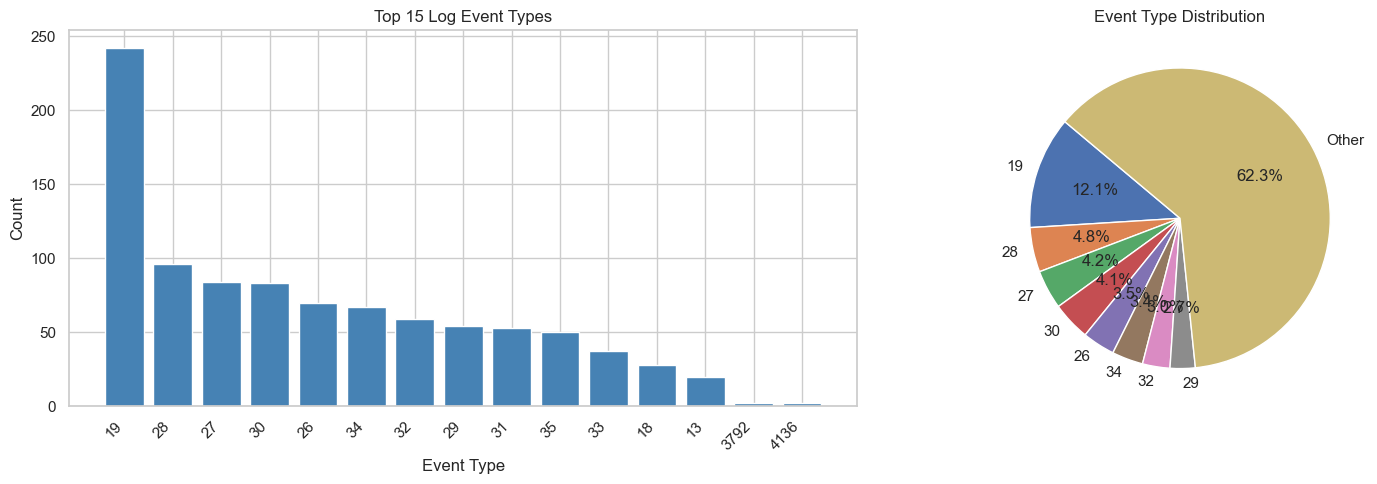

Plot saved


In [6]:
# Visualize event distribution
top_events = dict(event_counts.most_common(15))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
axes[0].bar(range(len(top_events)), list(top_events.values()), color='steelblue')
axes[0].set_xticks(range(len(top_events)))
axes[0].set_xticklabels(list(top_events.keys()), rotation=45, ha='right')
axes[0].set_xlabel('Event Type')
axes[0].set_ylabel('Count')
axes[0].set_title('Top 15 Log Event Types')

# Pie chart - top 8 + other
top8 = dict(event_counts.most_common(8))
other_count = sum(v for k, v in event_counts.items() if k not in top8)
pie_data = {**top8, 'Other': other_count}
axes[1].pie(pie_data.values(), labels=pie_data.keys(), autopct='%1.1f%%', startangle=140)
axes[1].set_title('Event Type Distribution')

plt.tight_layout()
plt.savefig('../data/processed/event_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print('Plot saved')

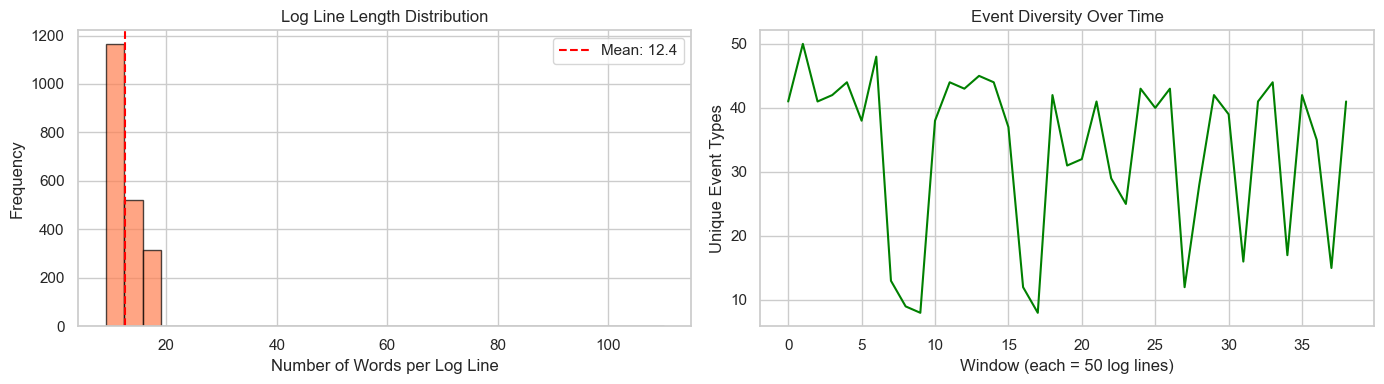

Avg line length: 12.4 words
Max line length: 110 words
Min line length: 9 words


In [7]:
# Log line length distribution
line_lengths = [len(line.split()) for line in logs]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(line_lengths, bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Words per Log Line')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Log Line Length Distribution')
axes[0].axvline(np.mean(line_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(line_lengths):.1f}')
axes[0].legend()

# Event frequency over time (sequential)
window = 50
event_series = pd.Series(events)
# Count non-UNKNOWN events per window
unique_per_window = [event_series[i:i+window].nunique() for i in range(0, len(event_series)-window, window)]

axes[1].plot(unique_per_window, color='green', linewidth=1.5)
axes[1].set_xlabel(f'Window (each = {window} log lines)')
axes[1].set_ylabel('Unique Event Types')
axes[1].set_title('Event Diversity Over Time')

plt.tight_layout()
plt.show()

print(f'Avg line length: {np.mean(line_lengths):.1f} words')
print(f'Max line length: {max(line_lengths)} words')
print(f'Min line length: {min(line_lengths)} words')

## 4. Preprocessing - Build Vocabulary and Sequences

In [8]:
from data_preprocessing import HDFSLogPreprocessor

# Run preprocessing
os.makedirs('../data/processed', exist_ok=True)
preprocessor = HDFSLogPreprocessor(config_path='../config.yaml')

# Use already-downloaded file
with open(log_path, 'r') as f:
    raw_logs = f.readlines()

events_processed = preprocessor.build_vocabulary(raw_logs)
sequences = preprocessor.create_sequences(events_processed)

print(f'Vocabulary size: {preprocessor.vocab_size}')
print(f'Total sequences: {len(sequences)}')
print(f'Sequence shape: {sequences.shape}')
print()
print('Sample sequence (event IDs):', sequences[0])

2026-04-17 09:54:53.142 | INFO     | data_preprocessing:build_vocabulary:58 - Building vocabulary...
2026-04-17 09:54:53.183 | INFO     | data_preprocessing:build_vocabulary:70 - Vocabulary size: 1056
2026-04-17 09:54:53.186 | INFO     | data_preprocessing:create_sequences:76 - Creating sequences of length 10
2026-04-17 09:54:53.191 | INFO     | data_preprocessing:create_sequences:88 - Created 1990 sequences


Vocabulary size: 1056
Total sequences: 1990
Sequence shape: (1990, 10)

Sample sequence (event IDs): [30 31 10 32 33  5  6  6 34 35]


In [11]:
from sklearn.model_selection import train_test_split

train_seq, test_seq = train_test_split(sequences, train_size=0.7, random_state=42)

# Save processed data
np.save('../data/processed/train_sequences.npy', train_seq)
np.save('../data/processed/test_sequences.npy', test_seq)
np.save('../data/processed/vocab.npy', preprocessor.vocab)

print(f'Train sequences: {train_seq.shape}')
print(f'Test sequences:  {test_seq.shape}')
print('Saved to data/processed/')

Train sequences: (1393, 10)
Test sequences:  (597, 10)
Saved to data/processed/


## 5. LSTM Autoencoder Training

In [13]:
from model_training import LSTMAutoencoder

os.makedirs('../models', exist_ok=True)

autoencoder = LSTMAutoencoder(config_path='../config.yaml')
history = autoencoder.train(train_seq, test_seq)

print('Training complete!')

2026-04-17 09:57:59.044 | INFO     | model_training:train:73 - Starting training...
2026-04-17 09:57:59.097 | INFO     | model_training:build_model:25 - Building LSTM Autoencoder...
C:\Users\smrit\anaconda3\envs\log-anomaly\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026-04-17 09:58:00.028 | INFO     | model_training:build_model:65 - Model architecture built


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 10)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding (Embedding)                │ (None, 10, 32)              │          33,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 64)                  │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ repeat_vector (RepeatVector)         │ (None, 10, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 10, 64)              │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed (TimeDistributed)   │ (None, 10, 1056)            │          68,640 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 160,288 (626.12 KB)

 Trainable params: 160,288 (626.12 KB)

...

INFO:tensorflow:Assets written to: models/lstm_saved_model\assets


INFO:tensorflow:Assets written to: models/lstm_saved_model\assets


Saved artifact at 'models/lstm_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10, 1056), dtype=tf.float32, name=None)
Captures:
  2244556573504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2244556573856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2244556574912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2244556573328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2244556574560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2244556574736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2244556574032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2244556575792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2244556576320: TensorSpec(shape=(), dtype=tf.resource, name=None)


2026-04-17 09:59:39.938 | INFO     | model_training:train:127 - Model and artifacts saved


Training complete!


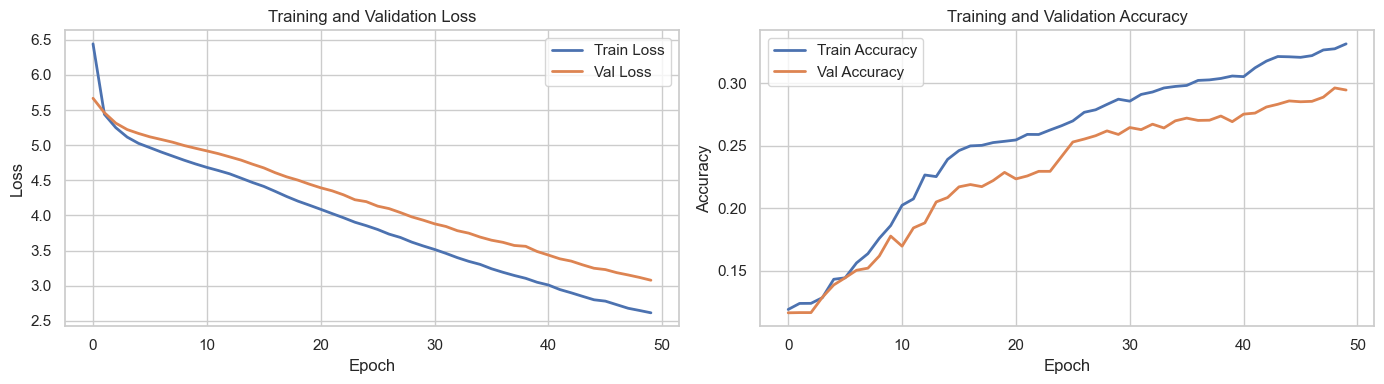

Final train loss:     2.6143
Final val loss:       3.0778
Final train accuracy: 0.3314
Final val accuracy:   0.2945


In [16]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/training_history.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Final train loss:     {history.history["loss"][-1]:.4f}')
print(f'Final val loss:       {history.history["val_loss"][-1]:.4f}')
print(f'Final train accuracy: {history.history["accuracy"][-1]:.4f}')
print(f'Final val accuracy:   {history.history["val_accuracy"][-1]:.4f}')

## 6. Reconstuction Error Analysis and Threshold Tuning

In [17]:
# Compute reconstruction errors on test set
test_predictions = autoencoder.model.predict(test_seq)

test_errors = np.mean(
    np.square(np.expand_dims(test_seq, -1) - test_predictions),
    axis=(1, 2)
)

print(f'Test set size: {len(test_errors)}')
print(f'Mean reconstruction error:   {np.mean(test_errors):.6f}')
print(f'Std reconstruction error:    {np.std(test_errors):.6f}')
print(f'Min reconstruction error:    {np.min(test_errors):.6f}')
print(f'Max reconstruction error:    {np.max(test_errors):.6f}')
print(f'95th percentile (threshold): {np.percentile(test_errors, 95):.6f}')

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
Test set size: 597
Mean reconstruction error:   201089.401689
Std reconstruction error:    213313.906390
Min reconstruction error:    0.998809
Max reconstruction error:    1025162.582406
95th percentile (threshold): 623399.018055


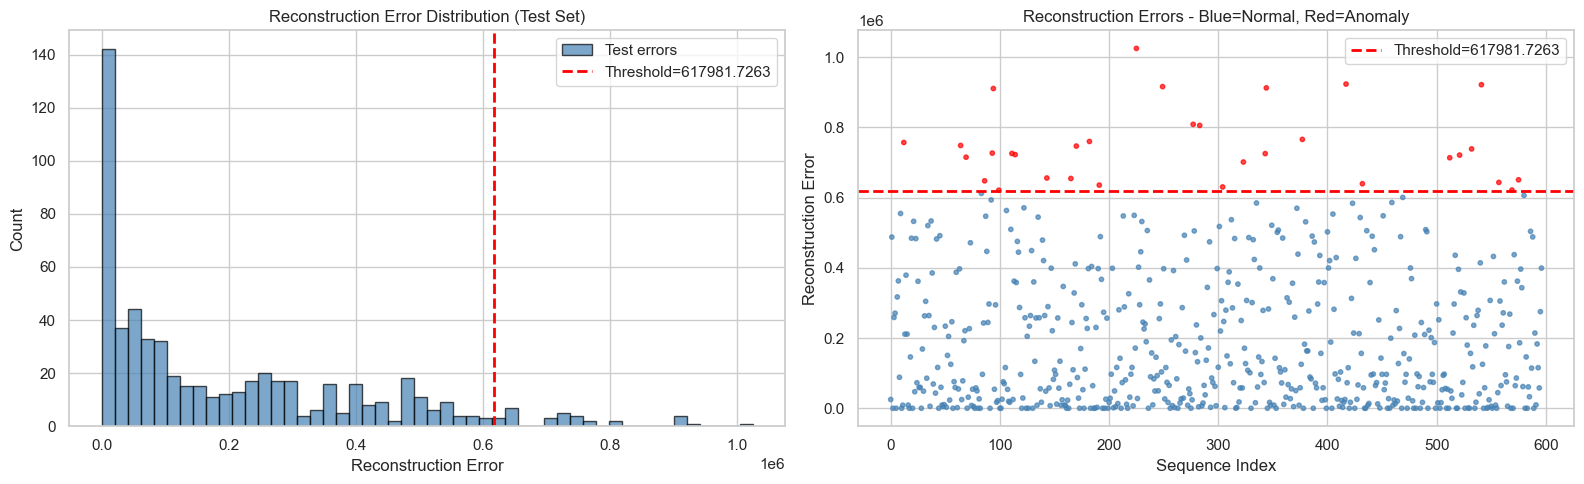

Normal sequences:   565 (94.6%)
Anomaly sequences:  32 (5.4%)


In [18]:
# Plot reconstruction error distribution
threshold = autoencoder.threshold

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
axes[0].hist(test_errors, bins=50, color='steelblue', edgecolor='black', alpha=0.7, label='Test errors')
axes[0].axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold={threshold:.4f}')
axes[0].set_xlabel('Reconstruction Error')
axes[0].set_ylabel('Count')
axes[0].set_title('Reconstruction Error Distribution (Test Set)')
axes[0].legend()

# Sequential plot
colors = ['red' if e > threshold else 'steelblue' for e in test_errors]
axes[1].scatter(range(len(test_errors)), test_errors, c=colors, s=10, alpha=0.7)
axes[1].axhline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold={threshold:.4f}')
axes[1].set_xlabel('Sequence Index')
axes[1].set_ylabel('Reconstruction Error')
axes[1].set_title('Reconstruction Errors - Blue=Normal, Red=Anomaly')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/reconstruction_errors.png', dpi=100, bbox_inches='tight')
plt.show()

anomaly_count = np.sum(test_errors > threshold)
normal_count = np.sum(test_errors <= threshold)
print(f'Normal sequences:   {normal_count} ({normal_count/len(test_errors)*100:.1f}%)')
print(f'Anomaly sequences:  {anomaly_count} ({anomaly_count/len(test_errors)*100:.1f}%)')

## 7. Model Evaluation

In [19]:
# Test anomaly detection on individual sequences
print('Testing anomaly detection on sample sequences:')
print('-' * 60)

for i in [0, 1, 2, -1, -2, -3]:
    sample = test_seq[i]
    result = autoencoder.detect_anomaly(sample)
    status = 'ANOMALY' if result['is_anomaly'] else 'Normal'
    print(f'Sequence {i:>4}: {status:<8} | error={result["reconstruction_error"]:.6f} | score={result["anomaly_score"]:.2f}x')

print('-' * 60)
print(f'Threshold: {autoencoder.threshold:.6f}')

Testing anomaly detection on sample sequences:
------------------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step
Sequence    0: Normal   | error=25015.102191 | score=0.04x
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
Sequence    1: Normal   | error=487697.167442 | score=0.79x
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
Sequence    2: Normal   | error=15.993168 | score=0.00x
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
Sequence   -1: Normal   | error=399331.526535 | score=0.65x
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
Sequence   -2: Normal   | error=275201.608933 | score=0.45x
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
Sequence   -3: Normal   | error=57958.645542 | score=0.09x
------------------------------------------------------------
Threshold: 617981.726299


In [21]:
# Threshold sensitivity analysis
print('Threshold sensitivity analysis:')
print(f"{'Percentile':<12} {'Threshold':<14} {'Anomaly %':<12}")
print('-' * 40)

for p in [90, 92, 95, 97, 99]:
    t = np.percentile(test_errors, p)
    pct = np.sum(test_errors > t) / len(test_errors) * 100
    marker = '<-- current' if p == 95 else ''
    print(f'{p:<12} {t:<14.6f} {pct:<12.1f}% {marker}')

Threshold sensitivity analysis:
Percentile   Threshold      Anomaly %   
----------------------------------------
90           508046.071106  10.1        % 
92           545347.695072  8.0         % 
95           623399.018055  5.0         % <-- current
97           721417.477147  3.0         % 
99           812933.764614  1.0         % 


## 8. Summary

The LSTM Autoencoder has been successfully trained on HDFS log sequences.

**Key results:**
- Dataset: 2,000 HDFS log lines parsed into event sequences
- Sequences: sliding window of length 10
- Architecture: Embedding → LSTM(64) → RepeatVector → LSTM(64) → Dense
- Anomaly detection: reconstruction error > 95th percentile threshold

**Next steps:**
1. Run `python src/deploy_model.py` to deploy to SageMaker
2. Run `bash aws_infrastructure/deploy.sh` to provision AWS infrastructure
3. Configure GitHub Actions secrets for CI/CD automation
4. Import `monitoring/grafana_dashboard.json` into Grafana